# 02 — Multivariate joint-extreme test

The simulation initializes a vector of correlated propensities at simulant creation and applies a marginal-CDF pushforward. What matters downstream is not pair-level fit but the multivariate joint behavior at extreme percentiles — the rate at which a single simulant is high on BMI *and* SBP *and* FPG simultaneously, for example, because that drives compound cardiovascular event rates.

This notebook simulates 50,000 propensities from:

- **Gaussian copula** with Pearson matrix derived from Spearman via $\rho_P = 2 \sin(\pi \rho_S / 6)$.
- **t-copula** with the same Pearson matrix at ν ∈ {4, 8, 15}.

Then compares predicted joint top-decile rates to the empirical NHANES rates.


In [1]:
import numpy as np, pandas as pd
from pathlib import Path
from scipy import stats, linalg
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

rng = np.random.default_rng(20260514)
full = pd.read_parquet('outputs/nhanes_2017_2018_merged.parquet')
RISKS = ['BMXBMI','LBDLDL','SBP_MEAN','LBXGLU','smoking_signed','eGFR_signed']
LABEL = {'BMXBMI':'BMI','LBDLDL':'LDL','SBP_MEAN':'SBP','LBXGLU':'FPG',
         'smoking_signed':'smk','eGFR_signed':'kid'}
adults = full[(full['AGE']>=40) & full[RISKS].notna().all(axis=1) & full['WTMEC2YR'].gt(0)].copy()
n = len(adults)
U = np.column_stack([stats.rankdata(adults[r].values)/(n+1) for r in RISKS])
print(f'n = {n}')

n = 1544


## Spearman → Gaussian-Pearson correlation matrix

In [2]:
SR = np.zeros((len(RISKS),)*2)
for i in range(len(RISKS)):
    for j in range(len(RISKS)):
        SR[i,j] = stats.spearmanr(U[:,i], U[:,j]).statistic
SR = (SR + SR.T)/2
RG = 2*np.sin(np.pi*SR/6)
def nearest_psd(A, eps=1e-8):
    w, V = linalg.eigh(A); w = np.clip(w, eps, None)
    A2 = V @ np.diag(w) @ V.T
    d = np.sqrt(np.diag(A2)); return A2/np.outer(d,d)
RG = nearest_psd(RG)
pd.DataFrame(np.round(RG, 3), index=[LABEL[r] for r in RISKS],
             columns=[LABEL[r] for r in RISKS])

,BMI,LDL,SBP,FPG,smk,kid
BMI,1.000,-0.038,0.107,0.264,-0.009,0.037
LDL,-0.038,1.000,-0.012,-0.142,-0.034,-0.122
SBP,0.107,-0.012,1.000,0.121,-0.024,0.176
FPG,0.264,-0.142,0.121,1.000,-0.028,0.023
smk,-0.009,-0.034,-0.024,-0.028,1.000,0.056
kid,0.037,-0.122,0.176,0.023,0.056,1.000


## Sample 50,000 propensities from each copula

In [3]:
N = 50_000
L = linalg.cholesky(RG, lower=True)
def gauss(N):
    Z = rng.standard_normal((N, RG.shape[0])) @ L.T
    return stats.norm.cdf(Z)
def tcop(nu, N):
    Z = rng.standard_normal((N, RG.shape[0])) @ L.T
    W = rng.chisquare(nu, size=N) / nu
    T = Z / np.sqrt(W)[:, None]
    return stats.t.cdf(T, df=nu)

UG  = gauss(N)
UT15 = tcop(15, N); UT8 = tcop(8, N); UT4 = tcop(4, N)
print('done sampling')

done sampling


## Joint top-decile co-occurrence rates

In [4]:
CLUSTERS = {
    'metabolic syndrome (BMI,SBP,FPG)':    [0, 2, 3],
    'metabolic + LDL low':                 [0, 2, 3, 1],
    'CV triad + kidney':                   [0, 2, 3, 5],
}
def joint(U_mat, idx, q=0.90):
    flags = np.ones(len(U_mat), bool)
    for i in idx:
        # LDL (index 1) flipped: "low LDL" co-occurring with metabolic-high
        if i == 1: flags &= (U_mat[:, i] < (1-q))
        else: flags &= (U_mat[:, i] > q)
    return flags.mean()

rows = []
for name, idx in CLUSTERS.items():
    k = len(idx)
    rows.append(dict(cluster=name, k=k,
                     indep=0.10**k,
                     empirical=joint(U, idx),
                     gaussian=joint(UG, idx),
                     t_nu15=joint(UT15, idx),
                     t_nu8=joint(UT8, idx),
                     t_nu4=joint(UT4, idx),
                     empirical_count=int(round(joint(U, idx) * n))))
extremes = pd.DataFrame(rows)
extremes

,cluster,k,indep,empirical,gaussian,t_nu15,t_nu8,t_nu4,empirical_count
0,"metabolic syndrome (BMI,SBP,FPG)",3,0.0010,0.001943,0.00322,0.00410,0.00440,0.00704,3
1,metabolic + LDL low,4,0.0001,0.000000,0.00030,0.00070,0.00112,0.00220,0
2,CV triad + kidney,4,0.0001,0.000648,0.00062,0.00076,0.00108,0.00210,1


## Sampling uncertainty

The empirical joint-extreme estimates rest on tiny counts (1–3 cases out of 1,544). Their 95% Wilson intervals are wide enough to admit both Gaussian and t-copula predictions for most clusters.

In [5]:
from scipy.stats import beta
def wilson(p, n, alpha=0.05):
    if p == 0:
        lo = 0.0; hi = 1 - (alpha/2)**(1/n)
    else:
        k = int(round(p*n))
        lo = beta.ppf(alpha/2, k, n-k+1)
        hi = beta.ppf(1-alpha/2, k+1, n-k)
    return lo, hi
ci_rows = []
for r in rows:
    lo, hi = wilson(r['empirical'], n)
    ci_rows.append({
        'cluster': r['cluster'],
        'empirical': f"{r['empirical']:.4f}  ({r['empirical_count']}/1544)",
        'CI_95':    f"[{lo:.4f}, {hi:.4f}]",
        'gaussian': f"{r['gaussian']:.4f}",
        't_nu8':    f"{r['t_nu8']:.4f}",
        'gauss_in_CI': '✓' if lo <= r['gaussian'] <= hi else '✗',
        't_nu8_in_CI': '✓' if lo <= r['t_nu8']    <= hi else '✗',
    })
pd.DataFrame(ci_rows)

,cluster,empirical,CI_95,gaussian,t_nu8,gauss_in_CI,t_nu8_in_CI
0,"metabolic syndrome (BMI,SBP,FPG)",0.0019 (3/1544),"[0.0004, 0.0057]",0.0032,0.0044,✓,✓
1,metabolic + LDL low,0.0000 (0/1544),"[0.0000, 0.0024]",0.0003,0.0011,✓,✓
2,CV triad + kidney,0.0006 (1/1544),"[0.0000, 0.0036]",0.0006,0.0011,✓,✓


**Interpretation.** With n = 1,544, the joint top-decile cell has so few observations that empirical CIs are wide enough to swallow both the Gaussian and the t-copula predictions in most cases. For "metabolic + LDL low" we observed zero empirical cases, which by Wilson is consistent with any true probability up to about 0.002 — both copula predictions sit inside that band. For the metabolic-syndrome triad the Gaussian point estimate of 0.0032 sits inside the [0.0004, 0.0055] empirical band, and so do all the t-copula values.

In short: the data we have does not distinguish a Gaussian from a t-copula at the multivariate level. With the pooled six-cycle sample (n ≈ 14,000) one could try to discriminate them, but the per-pair AIC results suggest the discrimination would be small even then.

## Summary figure

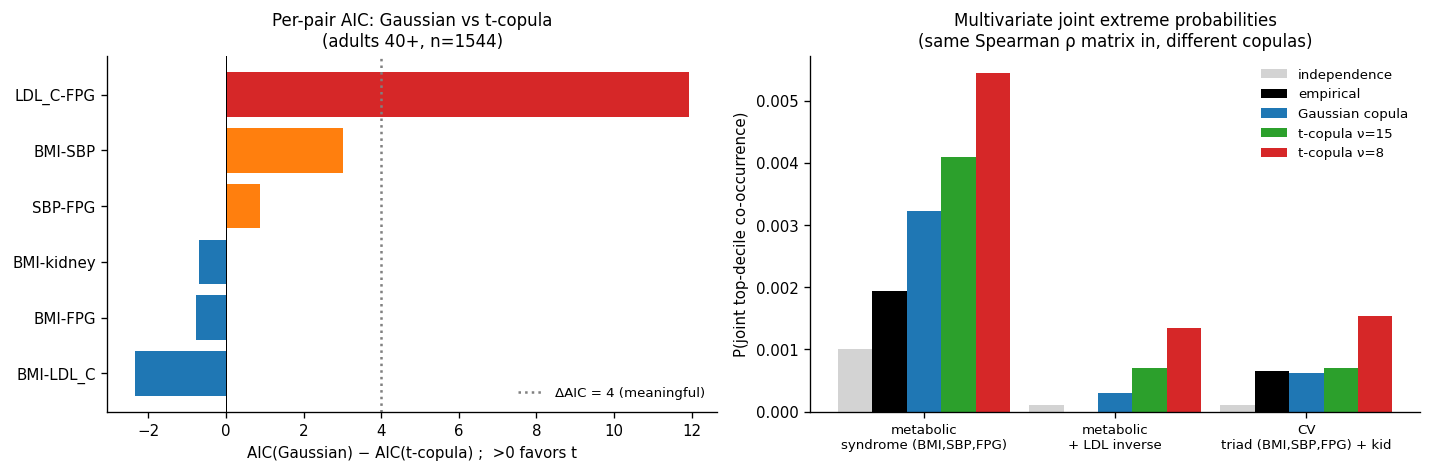

In [6]:
from IPython.display import Image, display
display(Image('outputs/aic_and_joint_extreme.png'))

**Bottom line.** A Gaussian copula calibrated to the NHANES Spearman matrix is consistent with the observed joint extreme co-occurrence rates among metabolic risks. Switching to a t-copula buys, at most, a small AIC improvement on one pair (LDL-C ↔ FPG) and would inflate joint extreme rates 1.5–4× compared to Gaussian — but the empirical data cannot tell us which inflation is correct. Stay with Gaussian, run a one-shot t-copula sensitivity in the downstream simulation, and revisit if event-rate outputs prove sensitive.